In [1]:
!pip install requests pandas numpy matplotlib seaborn scipy pytrends faker beautifulsoup4 lxml dash plotly selenium webdriver-manager


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

import re
import math
import time
import random
import warnings
import xml.etree.ElementTree as ET
from datetime import datetime, timedelta
from collections import defaultdict
from urllib.parse import urlparse, parse_qs, urlencode, urlunparse, urljoin


import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from bs4 import BeautifulSoup
from faker import Faker
from pytrends.request import TrendReq


import dash
import plotly.express as px
import plotly.graph_objects as go
from dash import dcc, html, Input, Output
from dash.dependencies import Input, Output


from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager


warnings.filterwarnings('ignore')

In [3]:
def parse_price_rub(value) -> float:
    if pd.isna(value):
        return None
    cleaned = re.sub(r"[^\d]", "", str(value))
    return float(cleaned) if cleaned else None

def parse_elements(value) -> int:
    if pd.isna(value):
        return None
    m = re.search(r"(\d[\d\s]*)\s*шт", str(value))
    if m:
        return int(re.sub(r"\s", "", m.group(1)))
    return None

def parse_size(value):
    if pd.isna(value):
        return None
    m = re.search(r"(\d+)[x*×](\d+)", str(value))
    if m:
        return float(m.group(1)), float(m.group(2))
    return None

def parse_price_usd(value) -> float:
    if pd.isna(value):
        return None
    cleaned = re.sub(r"[^\d.]", "", str(value))
    return float(cleaned) if cleaned else None

def parse_age(value) -> int:
    if pd.isna(value):
        return None
    m = re.search(r"(\d+)", str(value))
    return int(m.group(1)) if m else None

In [4]:
class ToysLandParser:
    """Парсер toys-land.ru"""

    def __init__(self, url: str, max_pages: int = None, delay: float = 1.0):
        self.base_url = url
        self.max_pages = max_pages
        self.delay = delay
        self.base_domain = "https://www.toys-land.ru"
        self.headers = {"User-Agent": "Mozilla/5.0"}
        self.products = []
        self.total_pages_parsed = 0

    def fetch_page(self, url: str) -> str:
        try:
            r = requests.get(url, headers=self.headers, timeout=10)
            r.raise_for_status()
            return r.text
        except requests.RequestException:
            return ""

    def build_page_url(self, page_number: int) -> str:
        parsed = urlparse(self.base_url)
        params = parse_qs(parsed.query)
        params["page"] = [str(page_number)]
        return urlunparse(parsed._replace(query=urlencode(params, doseq=True)))

    def get_total_pages(self, html: str) -> int:
        if not html:
            return 1
        soup = BeautifulSoup(html, "html.parser")
        pagination = (soup.find("div", class_="pagination")
                      or soup.find("ul", class_="pagination")
                      or soup.find("div", class_="nav-pages"))
        if pagination:
            nums = []
            for a in pagination.find_all("a"):
                try:
                    nums.append(int(a.text.strip()))
                except (ValueError, AttributeError):
                    pass
            if nums:
                return max(nums)
        return 1

    def parse_products(self, html: str) -> list:
        if not html:
            return []
        soup = BeautifulSoup(html, "html.parser")
        result = []
        for block in soup.find_all("div", class_="name"):
            link = block.find("a", class_="hint")
            if link:
                href = link.get("href", "")
                full_url = self.base_domain + href if href.startswith("/") else href
                span = link.find("span", itemprop="name")
                result.append({
                    "name": span.text.strip() if span else "",
                    "link": full_url,
                    "page": self.total_pages_parsed + 1,
                })
        return result

    def parse_all_pages(self) -> list:
        all_products = []
        first_html = self.fetch_page(self.base_url)
        if not first_html:
            return []
        all_products.extend(self.parse_products(first_html))
        self.total_pages_parsed = 1
        total = self.get_total_pages(first_html)
        if self.max_pages:
            total = min(total, self.max_pages)
        for page in range(2, total + 1):
            time.sleep(self.delay)
            html = self.fetch_page(self.build_page_url(page))
            if not html:
                continue
            prods = self.parse_products(html)
            if not prods:
                break
            all_products.extend(prods)
            self.total_pages_parsed = page
        self.products = all_products
        return all_products

    def run(self, use_pagination: bool = True) -> pd.DataFrame:
        if use_pagination:
            self.parse_all_pages()
        else:
            html = self.fetch_page(self.base_url)
            self.products = self.parse_products(html) if html else []
            self.total_pages_parsed = 1
        return pd.DataFrame(self.products)


url = "https://www.toys-land.ru/catalog/pazly/pazly-dlya-vzroslyh/"
parser = ToysLandParser(url, max_pages=5, delay=1.5)
df = parser.run(use_pagination=True)
display(df)

,name,link,page
0,"Пазл-репродукция Гончарова Н.С. - Подсолнухи, ...",https://www.toys-land.ru/goods/pazl-reprodukci...,1
1,"Пазл-репродукция Репин И.Е - На меже, 1500 эле...",https://www.toys-land.ru/goods/kartina-pazl-re...,1
2,"Пазл Германия - Ночь в Рамзау, 500 деталей",https://www.toys-land.ru/goods/pazl-germaniya-...,1
3,"Деревянный пазл Сальвадор Дали 40*40 см, 475 э...",https://www.toys-land.ru/goods/derevyannyj-paz...,1
4,"Пазл Парусная лодка, 1000 элементов",https://www.toys-land.ru/goods/pazl-parusnaya-...,1
...,...,...,...
88,"Пазл Парк Гуэль - Барселона, 500 элементов",https://www.toys-land.ru/goods/pazl-park-gujel...,2
89,"Пазл Цвета Азии, 1000 элементов",https://www.toys-land.ru/goods/pazl-cveta-azii...,2
90,Пазл-репродукция Жестокая преданность - Энн Ст...,https://www.toys-land.ru/goods/pazl-zhestokaya...,2
91,"Набор пазлов Загородный сад, 3*500 элементов",https://www.toys-land.ru/goods/nabor-pazlov-za...,2


In [5]:
class ProductParser:

    def __init__(self, delay: float = 0.5):
        self.delay = delay
        self.headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
        }

    def fetch_page(self, url: str) -> str:
        try:
            response = requests.get(url, headers=self.headers, timeout=10)
            response.raise_for_status()
            return response.text
        except requests.RequestException:
            return ""

    def parse_product_details(self, html: str, product_url: str) -> dict:
        if not html:
            return {}

        soup = BeautifulSoup(html, 'html.parser')

        product_info = {
            'url': product_url,
            'name': self._parse_product_name(soup),
            'manufacturer': '',
            'manufacturer_url': '',
            'country': '',
            'article': '',
            'price': '',
            'puzzle_size': '',
            'elements_count': '',
            'material': '',
            'packaging': '',
            'description': ''
        }

        self._parse_characteristics_table(soup, product_info)
        self._parse_characteristics_list(soup, product_info)
        self._parse_description(soup, product_info)

        return product_info

    def _parse_product_name(self, soup) -> str:
        name_selectors = [
            ('h1', {}),
            ('div', {'class': 'product-name'}),
            ('span', {'itemprop': 'name'}),
            ('div', {'class': 'name'})
        ]

        for tag, attrs in name_selectors:
            element = soup.find(tag, attrs)
            if element:
                return element.text.strip()

        return ''

    def _parse_characteristics_table(self, soup, product_info: dict):
        tables = soup.find_all('table')

        for table in tables:
            tbody = table.find('tbody')
            if not tbody:
                continue

            rows = tbody.find_all('tr')

            for row in rows:
                cells = row.find_all('td')
                if len(cells) >= 2:
                    label = cells[0].text.strip()
                    value_cell = cells[1]

                    if 'Изготовитель' in label or 'Производитель' in label:
                        link = value_cell.find('a')
                        if link:
                            product_info['manufacturer'] = link.text.strip()
                            product_info['manufacturer_url'] = link.get('href', '')
                        else:
                            product_info['manufacturer'] = value_cell.text.strip()

                    elif 'Страна' in label:
                        product_info['country'] = value_cell.text.strip()

                    elif 'Артикул' in label:
                        product_info['article'] = value_cell.text.strip()

                    elif 'Цена' in label or 'цена' in label.lower():
                        price_text = value_cell.text.strip()
                        product_info['price'] = self._clean_price(price_text)

    def _parse_characteristics_list(self, soup, product_info: dict):
        lists = soup.find_all('ul')

        for ul in lists:
            items = ul.find_all('li')

            for item in items:
                text = item.text.strip()

                if 'Размер' in text and ('пазл' in text.lower() or 'собран' in text.lower()):
                    product_info['puzzle_size'] = self._extract_value(text, 'Размер')

                elif 'Количество элементов' in text or 'элементов' in text.lower():
                    product_info['elements_count'] = self._extract_value(text, 'элементов')

                elif 'Материал' in text:
                    product_info['material'] = self._extract_value(text, 'Материал')

                elif 'Упаковка' in text:
                    product_info['packaging'] = self._extract_value(text, 'Упаковка')

    def _parse_description(self, soup, product_info: dict):
        description_selectors = [
            ('div', {'class': 'description'}),
            ('div', {'itemprop': 'description'}),
            ('div', {'class': 'product-description'}),
            ('div', {'id': 'description'})
        ]

        for tag, attrs in description_selectors:
            element = soup.find(tag, attrs)
            if element:
                product_info['description'] = element.text.strip()
                break

    def _extract_value(self, text: str, keyword: str) -> str:
        value = text.replace(keyword, '').strip()
        if value.startswith(':'):
            value = value[1:].strip()
        return value

    def _clean_price(self, price_text: str) -> str:
        return price_text.strip()

    def parse_product(self, url: str) -> dict:
        html = self.fetch_page(url)

        if not html:
            return {}

        product_info = self.parse_product_details(html, url)
        time.sleep(self.delay)

        return product_info

    def parse_multiple_products(self, urls: list) -> "pd.DataFrame":
        all_products = []

        for i, url in enumerate(urls, 1):
            product_info = self.parse_product(url)

            if product_info:
                all_products.append(product_info)

            if i % 10 == 0:
                time.sleep(2)

        df = pd.DataFrame(all_products)
        return df


product_parser = ProductParser(delay=1.0)

urls = list(df["link"])
df_multiple = product_parser.parse_multiple_products(urls)
display(df_multiple)

,url,name,manufacturer,manufacturer_url,country,article,price,puzzle_size,elements_count,material,packaging,description
0,https://www.toys-land.ru/goods/pazl-reprodukci...,"Пазл-репродукция Гончарова Н.С. - Подсолнухи, ...",Стелла,/brand/stella,Россия,TG100106,940 ₽,собранного пазла: 68*48 см.,Количество : 1000 шт.,картон.,красочная картонная коробка.,
1,https://www.toys-land.ru/goods/kartina-pazl-re...,"Пазл-репродукция Репин И.Е - На меже, 1500 эле...",Стелла,/brand/stella,Россия,150229,1 110 ₽,собранного пазла: 85*58 см.,Количество : 1500 шт.,картон.,красочная картонная коробка.,
2,https://www.toys-land.ru/goods/pazl-germaniya-...,"Пазл Германия - Ночь в Рамзау, 500 деталей",Castorland (Касторлэнд),/brand/castorland,Польша,B-53063,360 ₽,собранного пазла: 47*33 см.,Количество : 500 шт.,картон.,красочная картонная коробка.,
3,https://www.toys-land.ru/goods/derevyannyj-paz...,"Деревянный пазл Сальвадор Дали 40*40 см, 475 э...",Active Puzzles (Актив Пазл),/brand/active-puzzles,Россия,1035-activepuzzles,4 200 ₽,собранного пазла: 40*40 см.,Количество : 475 шт.,дерево (береза).,деревянная коробка.,
4,https://www.toys-land.ru/goods/pazl-parusnaya-...,"Пазл Парусная лодка, 1000 элементов",Educa (Эдука),/brand/educa,Испания,18490,1 326 ₽,собранного пазла: 68*48 см.,Количество : 1000 шт.,картон.,красочная картонная коробка.,
...,...,...,...,...,...,...,...,...,...,...,...,...
82,https://www.toys-land.ru/goods/pazl-park-gujel...,"Пазл Парк Гуэль - Барселона, 500 элементов",Educa (Эдука),/brand/educa,Испания,15319,1 190 ₽,собранного пазла: 48*34 см.,Количество : 500 шт.,картон.,красочная картонная коробка.,
83,https://www.toys-land.ru/goods/pazl-cveta-azii...,"Пазл Цвета Азии, 1000 элементов",Educa (Эдука),/brand/educa,Испания,16294,1 380 ₽,собранного пазла: 48*68 см.,Количество : 1000 шт.,картон.,красочная картонная коробка.,
84,https://www.toys-land.ru/goods/pazl-zhestokaya...,Пазл-репродукция Жестокая преданность - Энн Ст...,Educa (Эдука),/brand/educa,Испания,17692,1 560 ₽,собранного пазла: 68*48 см.,Количество : 1000 шт.,картон.,красочная картонная коробка.,
85,https://www.toys-land.ru/goods/nabor-pazlov-za...,"Набор пазлов Загородный сад, 3*500 элементов",Educa (Эдука),/brand/educa,Испания,17965,1 777 ₽,одного пазла: 40*40.5 см.,Количество : 3*500 шт.,картон.,красочная картонная коробка.,


In [6]:
def parse_price(value) -> float | None:
    """Извлекает числовое значение цены"""
    if pd.isna(value):
        return None
    cleaned = re.sub(r"[^\d]", "", str(value))
    return float(cleaned) if cleaned else None


def parse_elements(value) -> int | None:
    """количество элементов"""
    if pd.isna(value):
        return None
    match = re.search(r"(\d[\d\s]*)\s*шт", str(value))
    if match:
        return int(re.sub(r"\s", "", match.group(1)))
    return None


def parse_size(value) -> tuple[float, float] | None:
    """ширина, высота"""
    if pd.isna(value):
        return None
    match = re.search(r"(\d+)[x*×](\d+)", str(value))
    if match:
        return float(match.group(1)), float(match.group(2))
    return None


,price_rub,elements,price_per_element
count,78.00,78.00,78.00
mean,1708.51,800.31,4.42
std,775.33,451.79,5.17
min,300.00,70.00,0.42
25%,1295.00,467.50,1.33
50%,1560.00,1000.00,1.68
75%,2041.75,1000.00,7.32
max,4490.00,1500.00,20.86


,count,avg_price,avg_elements,avg_price_per_el
manufacturer,,,,
Active Puzzles (Актив Пазл),19,2307.37,211.84,12.71
Ravensburger (Равенсбургер),5,1973.80,819.80,3.42
Heye (Хэйе),2,1950.00,1000.00,1.95
Educa (Эдука),35,1681.86,988.57,1.89
Clementoni (Клементони),1,1490.00,1000.00,1.49
Art Puzzle (Арт Пазл),5,1348.00,1100.00,1.25
Стелла,5,1178.00,1400.00,0.85
Castorland (Касторлэнд),6,445.00,700.00,0.69


,count,avg_price,median_price,avg_price_per_el
country,,,,
Россия,24,2072.08,1805.0,10.24
Германия,7,1967.00,1950.0,3.00
Испания,35,1681.86,1670.0,1.89
Италия,1,1490.00,1490.0,1.49
Турция,5,1348.00,1290.0,1.25
Польша,6,445.00,430.0,0.69


,count
price_rub,
до 500 ₽,4
500–1 000 ₽,4
1 000–2 000 ₽,49
2 000–5 000 ₽,21
5 000+ ₽,0


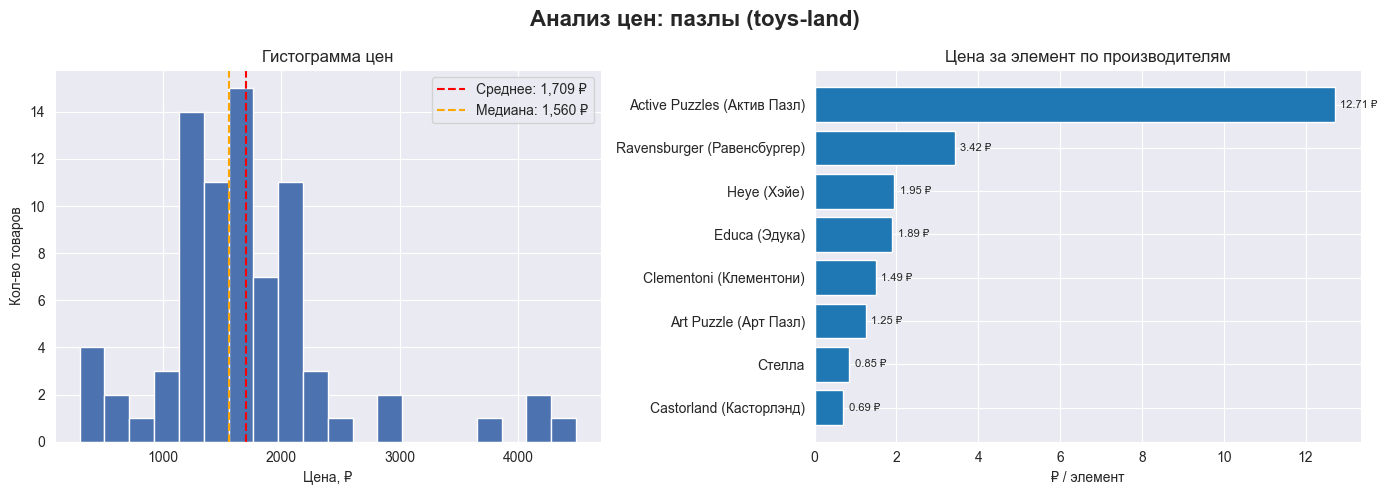

In [7]:
class PuzzlePriceAnalyzer:
    """Анализ цен toys-land"""

    def __init__(self, df: pd.DataFrame):
        self.raw = df.copy()
        self.df = self._clean(df)

    def _clean(self, df: pd.DataFrame) -> pd.DataFrame:
        d = df.copy()
        d["price_rub"] = d["price"].apply(parse_price_rub)
        d["elements"] = d["elements_count"].apply(parse_elements)
        sizes = d["puzzle_size"].apply(parse_size)
        d["size_w"] = sizes.apply(lambda x: x[0] if x else None)
        d["size_h"] = sizes.apply(lambda x: x[1] if x else None)
        d["size_area"] = d["size_w"] * d["size_h"]
        d = d.dropna(subset=["price_rub", "elements"])
        d["price_per_element"] = d["price_rub"] / d["elements"]
        return d

    def summary(self) -> pd.DataFrame:
        return self.df[["price_rub", "elements", "price_per_element"]].describe().round(2)

    def by_manufacturer(self) -> pd.DataFrame:
        return (
            self.df.groupby("manufacturer")
            .agg(
                count=("price_rub", "count"),           # ИСПРАВЛЕНО: "size" → "count"
                avg_price=("price_rub", "mean"),
                avg_elements=("elements", "mean"),
                avg_price_per_el=("price_per_element", "mean"),
            )
            .round(2)
            .sort_values("avg_price", ascending=False)
        )

    def by_country(self) -> pd.DataFrame:
        return (
            self.df.groupby("country")
            .agg(
                count=("price_rub", "count"),           # ИСПРАВЛЕНО: "size" → "count"
                avg_price=("price_rub", "mean"),
                median_price=("price_rub", "median"),
                avg_price_per_el=("price_per_element", "mean"),
            )
            .round(2)
            .sort_values("avg_price", ascending=False)
        )

    def price_segments(self) -> pd.Series:
        bins = [0, 500, 1000, 2000, 5000, np.inf]
        labels = ["до 500 ₽", "500–1 000 ₽", "1 000–2 000 ₽", "2 000–5 000 ₽", "5 000+ ₽"]
        return (
            pd.cut(self.df["price_rub"], bins=bins, labels=labels)
            .value_counts(sort=False)       # ИСПРАВЛЕНО: sort=False сохраняет порядок категорий
            .sort_index()
        )

    def plot_static(self) -> plt.Figure:
        df = self.df
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle("Анализ цен: пазлы (toys-land)", fontsize=16, fontweight="bold")

        ax = axes[0]
        ax.hist(df["price_rub"], bins=20, color="#4C72B0", edgecolor="white")
        ax.axvline(df["price_rub"].mean(), color="red", ls="--",
                   label=f"Среднее: {df['price_rub'].mean():,.0f} ₽")
        ax.axvline(df["price_rub"].median(), color="orange", ls="--",
                   label=f"Медиана: {df['price_rub'].median():,.0f} ₽")
        ax.set_xlabel("Цена, ₽")
        ax.set_ylabel("Кол-во товаров")
        ax.set_title("Гистограмма цен")
        ax.legend()

        ax = axes[1]
        ppe = df.groupby("manufacturer")["price_per_element"].mean().sort_values()
        bars = ax.barh(ppe.index, ppe.values)
        ax.bar_label(bars, fmt="%.2f ₽", padding=4, fontsize=8)
        ax.set_xlabel("₽ / элемент")
        ax.set_title("Цена за элемент по производителям")

        plt.tight_layout()
        return fig

    def run_dash(self, port: int = 8063):
        """Запуск дашборда"""
        df = self.df
        manufacturers = sorted(df["manufacturer"].dropna().unique())
        countries = sorted(df["country"].dropna().unique())

        app = dash.Dash(__name__)
        app.layout = html.Div([
            html.H2("Анализ цен: toys-land", style={"textAlign": "center"}),
            html.Div([
                html.Div([
                    html.Label("Производитель:"),
                    dcc.Dropdown(
                        id="dd-mfr",
                        options=[{"label": "Все", "value": "all"}] +
                                [{"label": m, "value": m} for m in manufacturers],
                        value="all",
                        clearable=False,
                    ),
                ], style={"width": "260px"}),
                html.Div([
                    html.Label("Страна:"),
                    dcc.Dropdown(
                        id="dd-country",
                        options=[{"label": "Все", "value": "all"}] +
                                [{"label": c, "value": c} for c in countries],
                        value="all",
                        clearable=False,
                    ),
                ], style={"width": "200px"}),
            ], style={"display": "flex", "gap": "20px", "padding": "10px"}),
            html.Div([
                dcc.Graph(id="hist-price"),
                dcc.Graph(id="bar-ppe"),
            ], style={"display": "grid", "gridTemplateColumns": "1fr 1fr", "gap": "12px"}),
        ])

        @app.callback(
            Output("hist-price", "figure"),
            Output("bar-ppe", "figure"),
            Input("dd-mfr", "value"),
            Input("dd-country", "value"),
        )
        def update(mfr, country):
            d = df.copy()
            if mfr != "all":
                d = d[d["manufacturer"] == mfr]
            if country != "all":
                d = d[d["country"] == country]

            fig_hist = px.histogram(
                d, x="price_rub", nbins=20,
                title="Распределение цен",
                labels={"price_rub": "Цена, ₽"},
                template="plotly_white",
                color_discrete_sequence=["#4C72B0"],
            )
            ppe_df = (
                d.groupby("manufacturer")["price_per_element"]
                .mean()
                .reset_index()
                .sort_values("price_per_element")
            )
            fig_bar = px.bar(
                ppe_df, x="price_per_element", y="manufacturer",
                orientation="h",
                title="Цена за элемент",
                labels={"price_per_element": "₽/элемент", "manufacturer": ""},
                template="plotly_white",
                text_auto=".2f",
            )
            return fig_hist, fig_bar

        app.run(port=port)


analyzer = PuzzlePriceAnalyzer(df_multiple)
display(analyzer.summary())
display(analyzer.by_manufacturer())
display(analyzer.by_country())
display(analyzer.price_segments().to_frame())
fig = analyzer.plot_static()
plt.show()
analyzer.run_dash()

In [8]:
class PuzzleWarehouseParser:
    def __init__(self):
        self.base_url = "https://www.puzzlewarehouse.com"
        self.jigsaw_url = f"{self.base_url}/jigsaw-puzzles/"
        self.session = requests.Session()
        self.headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
            'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
            'Accept-Language': 'en-US,en;q=0.9,ru;q=0.8',
            'Accept-Encoding': 'gzip, deflate, br',
            'Connection': 'keep-alive',
            'Upgrade-Insecure-Requests': '1',
            'Sec-Fetch-Dest': 'document',
            'Sec-Fetch-Mode': 'navigate',
            'Sec-Fetch-Site': 'none',
            'Sec-Fetch-User': '?1',
            'Cache-Control': 'max-age=0',
            'DNT': '1',
        }
        self.session.headers.update(self.headers)

    def get_page(self, url: str, retries: int = 3):
        for attempt in range(retries):
            try:
                response = self.session.get(url, timeout=30)
                if response.status_code == 200:
                    return BeautifulSoup(response.content, 'html.parser')
                elif response.status_code == 403:
                    print(f"Доступ запрещен (403). Попытка {attempt + 1}/{retries}")
                    time.sleep(5 * (attempt + 1))
                else:
                    print(f"Ошибка HTTP {response.status_code}. Попытка {attempt + 1}/{retries}")
                    time.sleep(2)
            except requests.RequestException as e:
                print(f"Ошибка запроса: {e}. Попытка {attempt + 1}/{retries}")
                time.sleep(3)
        return None

    def extract_puzzle_info(self, product_thumb) -> dict:
        try:
            img_tag = product_thumb.find('img')
            if not img_tag or not img_tag.get('title'):
                return None
            name = img_tag['title']

            link_tag = product_thumb.find('a')
            if not link_tag or not link_tag.get('href'):
                return None
            link = link_tag['href']
            if not link.startswith('http'):
                link = urljoin(self.base_url, link)

            parent_element = product_thumb.parent
            piece_count_element = None

            if parent_element:
                piece_count_element = parent_element.find('div', class_='piece-count')

            if not piece_count_element:
                piece_count_element = product_thumb.find_next('div', class_='piece-count')

            pieces = None
            if piece_count_element:
                piece_text = piece_count_element.get_text(strip=True)
                match = re.search(r'(\d+)\s*Pieces?', piece_text)
                if match:
                    pieces = int(match.group(1))

            if not pieces:
                match = re.search(r'(\d+)\s*[Pp]ieces?', name)
                if match:
                    pieces = int(match.group(1))

            return {
                'name': name,
                'link': link,
                'pieces': pieces if pieces else 'Unknown'
            }
        except Exception as e:
            print(f"Ошибка при извлечении информации: {e}")
            return None

    def build_page_url(self, page_number: int, params: dict = None) -> str:
        if params is None:
            params = {
                'aid': '',
                'pcs': '',
                'cid': '',
                'sort': 'mostPopular',
                'show': '48',
                'stock': '1',
                'budget_from': '0',
                'budget_to': '0',
                'price': '0',
            }
        params['page'] = str(page_number)
        query_string = urlencode(params)
        return f"{self.jigsaw_url}?{query_string}"

    def get_total_pages(self, soup) -> int:
        pagination = soup.find('ul', class_='pagination')
        if pagination:
            page_links = pagination.find_all('a')
            page_numbers = []
            for link in page_links:
                try:
                    num = int(link.text.strip())
                    page_numbers.append(num)
                except ValueError:
                    continue
            if page_numbers:
                return max(page_numbers)

        product_count = len(soup.find_all('div', class_='product-thumb'))
        if product_count == 0:
            return 0
        return 1

    def parse_all_pages(self, max_pages: int = None, start_page: int = 1) -> list:
        all_puzzles = []
        page = start_page

        if max_pages is None:
            first_url = self.build_page_url(1)
            first_soup = self.get_page(first_url)
            if first_soup:
                max_pages = self.get_total_pages(first_soup)
            else:
                max_pages = 1

        while page <= max_pages:
            url = self.build_page_url(page)

            soup = self.get_page(url)

            if not soup:
                print(f"Не удалось загрузить страницу {page}")
                page += 1
                continue

            product_thumbs = soup.find_all('div', class_='product-thumb')
            if not product_thumbs:
                print(f"На странице {page} нет товаров")
                break

            for thumb in product_thumbs:
                puzzle_info = self.extract_puzzle_info(thumb)
                if puzzle_info:
                    all_puzzles.append(puzzle_info)

            page += 1
            time.sleep(2)

        return all_puzzles

    def get_dataframe(self, max_pages: int = None, start_page: int = 1) -> "pd.DataFrame":
        puzzles = self.parse_all_pages(max_pages, start_page)
        df = pd.DataFrame(puzzles, columns=['name', 'link', 'pieces'])
        return df

In [9]:
parser = PuzzleWarehouseParser()
df = parser.get_dataframe(max_pages=1)

display(df)

,name,link,pieces
0,A Summer Kiss Mother's Day By SunsOut,https://www.puzzlewarehouse.com/a-summer-kiss-...,300
1,Haunted House on the Hill Halloween By MasterP...,https://www.puzzlewarehouse.com/haunted-house-...,1000
2,Kids Favorite Foods Nostalgic & Retro By Maste...,https://www.puzzlewarehouse.com/kids-favorite-...,1000
3,Off To See the Wizard Nostalgic & Retro By Mas...,https://www.puzzlewarehouse.com/off-to-see-the...,1000
4,An American Birdhouse Fourth of July By Master...,https://www.puzzlewarehouse.com/an-american-bi...,300
5,Rockefeller Center Joy - Re-release Christmas ...,https://www.puzzlewarehouse.com/rockefeller-ce...,1000
6,Bob's Beer & Bait General Store By Cobble Hill,https://www.puzzlewarehouse.com/bobs-beer-bait...,1000
7,Sidewalk Sale Shopping By GoodWay Puzzles,https://www.puzzlewarehouse.com/sidwalk-sale-g...,500
8,Snowy Afternoon Friends Christmas By MasterPieces,https://www.puzzlewarehouse.com/snowy-afternoo...,300
9,The Old Filling Station Americana By MasterPieces,https://www.puzzlewarehouse.com/the-old-fillin...,1000


In [14]:
import time
from datetime import datetime

class PuzzleDetailParser:
    """Детали одного товара"""

    def __init__(self):
        self.base_url = "https://www.puzzlewarehouse.com"
        self.session = requests.Session()
        self.session.headers.update({"User-Agent": "Mozilla/5.0"})

    def get_page(self, url: str, retries: int = 3):
        for attempt in range(retries):
            try:
                r = self.session.get(url, timeout=30)
                if r.status_code == 200:
                    return BeautifulSoup(r.content, "html.parser")
                time.sleep(5 * (attempt + 1))
            except requests.RequestException:
                time.sleep(3)
        return None

    def _find_td_value(self, soup, key: str) -> str:
        for row in soup.find_all("tr"):
            cells = row.find_all("td")
            if len(cells) >= 2 and cells[0].get_text(strip=True) == key:
                return cells[1].get_text(strip=True)
        return None

    def parse_puzzle_details(self, url: str) -> dict:
        soup = self.get_page(url)
        if not soup:
            return None
        h1 = soup.find("h1")
        price_el = soup.find("span", class_="product-unit-price")
        pce_el = soup.find("div", class_="piece-count")
        pieces = None
        if pce_el:
            m = re.search(r"(\d+)", pce_el.get_text())
            if m:
                pieces = int(m.group(1))
        return {
            "name": h1.text.strip() if h1 else None,
            "url": url,
            "price": price_el.text.strip() if price_el else None,
            "pieces": pieces or "Unknown",
            "age": self._find_td_value(soup, "Age"),
            "puzzle_category": self._find_td_value(soup, "Puzzle Category"),
        }

    def parse_multiple_puzzles(self, urls: list) -> pd.DataFrame:
        results = []
        total = len(urls)

        for i, url in enumerate(urls, 1):
            data = self.parse_puzzle_details(url)
            if data:
                results.append(data)


            if i % 50 == 0 or i == total:

                print(f"Обработано: {i}")

            time.sleep(1)


        return pd.DataFrame(results)


class PuzzleWarehouseFullParser:
    """Полный парсер с деталями"""

    def __init__(self):
        self.base_url = "https://www.puzzlewarehouse.com"
        self.jigsaw_url = "https://www.puzzlewarehouse.com/jigsaw-puzzles/"
        self.session = requests.Session()
        self.session.headers.update({"User-Agent": "Mozilla/5.0"})
        self.detail_parser = PuzzleDetailParser()
        self.detail_parser.session = self.session

    def get_page(self, url: str, retries: int = 3):
        for attempt in range(retries):
            try:
                r = self.session.get(url, timeout=30)
                if r.status_code == 200:
                    return BeautifulSoup(r.content, "html.parser")
                time.sleep(5 * (attempt + 1))
            except requests.RequestException:
                time.sleep(3)
        return None

    def build_page_url(self, page: int) -> str:
        params = {"sort": "mostPopular", "show": "48", "stock": "1",
                  "budget_from": "0", "budget_to": "0", "price": "0", "page": str(page)}
        return self.jigsaw_url + "?" + urlencode(params)

    def extract_product_links(self, soup) -> list:
        links = []
        for thumb in soup.find_all("div", class_="product-thumb"):
            a = thumb.find("a")
            if a and a.get("href"):
                link = a["href"]
                if not link.startswith("http"):
                    link = urljoin(self.base_url, link)
                links.append(link)
        return links

    def parse_catalog_with_details(self, max_pages: int = 1) -> pd.DataFrame:
        all_links = []


        for page in range(1, max_pages + 1):
            soup = self.get_page(self.build_page_url(page))

            links = self.extract_product_links(soup)

            all_links.extend(links)
            print(f"Страница {page}: найдено {len(links)} товаров (всего: {len(all_links)})")
            time.sleep(0.5)

        return self.detail_parser.parse_multiple_puzzles(all_links)


full_parser = PuzzleWarehouseFullParser()
df_full = full_parser.parse_catalog_with_details(max_pages=20)
display(df_full)

Страница 1: найдено 48 товаров (всего: 48)
Страница 2: найдено 48 товаров (всего: 96)
Страница 3: найдено 48 товаров (всего: 144)
Страница 4: найдено 48 товаров (всего: 192)
Страница 5: найдено 48 товаров (всего: 240)
Страница 6: найдено 48 товаров (всего: 288)
Страница 7: найдено 48 товаров (всего: 336)
Страница 8: найдено 48 товаров (всего: 384)
Страница 9: найдено 48 товаров (всего: 432)
Страница 10: найдено 48 товаров (всего: 480)
Страница 11: найдено 48 товаров (всего: 528)
Страница 12: найдено 48 товаров (всего: 576)
Страница 13: найдено 48 товаров (всего: 624)
Страница 14: найдено 48 товаров (всего: 672)
Страница 15: найдено 48 товаров (всего: 720)
Страница 16: найдено 48 товаров (всего: 768)
Страница 17: найдено 48 товаров (всего: 816)
Страница 18: найдено 48 товаров (всего: 864)
Страница 19: найдено 48 товаров (всего: 912)
Страница 20: найдено 48 товаров (всего: 960)
Обработано: 50
Обработано: 100
Обработано: 150
Обработано: 200
Обработано: 250
Обработано: 300
Обработано: 350


,name,url,price,pieces,age,puzzle_category
0,A Summer Kiss - 300 Piece Jigsaw Puzzle by Sun...,https://www.puzzlewarehouse.com/a-summer-kiss-...,$13.59,300,8+,Animals & Wildlife
1,Haunted House on the Hill - 1000 Piece Jigsaw ...,https://www.puzzlewarehouse.com/haunted-house-...,$20.99,300,11+,Holidays
2,Kids Favorite Foods - 1000 Piece Jigsaw Puzzle...,https://www.puzzlewarehouse.com/kids-favorite-...,$20.99,300,11+,Food & Drink
3,Off To See the Wizard - 1000 Piece Jigsaw Puzz...,https://www.puzzlewarehouse.com/off-to-see-the...,$16.80,300,11+,Pop Culture
4,An American Birdhouse - 300 Piece Jigsaw Puzzl...,https://www.puzzlewarehouse.com/an-american-bi...,$12.80,300,10+,Animals & Wildlife
...,...,...,...,...,...,...
955,Harvest Breeze - 300 Piece Jigsaw Puzzle by Ma...,https://www.puzzlewarehouse.com/masterpieces-h...,$12.95,300,10+,Landscapes & Scenery
956,Gathering at Yellowstone - 300 Piece Jigsaw Pu...,https://www.puzzlewarehouse.com/gathering-at-y...,$15.99,300,8+,Landscapes & Scenery
957,Funky Sea Critters - 500 Piece Jigsaw Puzzle b...,https://www.puzzlewarehouse.com/goodway-puzzle...,$21.99,300,None,Art
958,American Grill - 550 Piece Jigsaw Puzzle by Ro...,https://www.puzzlewarehouse.com/roseart-rosear...,$17.99,300,10+,Nostalgia


,price_usd,pieces,price_per_piece
count,960.0000,960.0,960.0000
mean,19.2292,300.0,0.0641
std,5.1425,0.0,0.0171
min,5.9900,300.0,0.0200
25%,15.9900,300.0,0.0533
50%,18.9900,300.0,0.0633
75%,20.9900,300.0,0.0700
max,51.9900,300.0,0.1733


,count,mean,median,std
puzzle_category,,,,
Fantasy & Gothic,8,27.58,21.49,12.51
"Graphics & Cartoons, Holidays",1,24.99,24.99,NaN
Graphics & Cartoons,16,23.00,24.99,5.02
History & Geography,8,21.97,18.49,10.61
Pop Culture,20,21.47,18.42,7.43
Art,16,21.33,20.90,3.13
"Graphics & Cartoons, Landscapes & Scenery",1,20.99,20.99,NaN
"Animals & Wildlife, Landscapes & Scenery",1,20.99,20.99,NaN
"Art, Collages & Assortments",1,20.99,20.99,NaN


,count,avg_price,avg_pieces
min_age,,,
3.0,18,10.13,300.0
4.0,6,16.89,300.0
5.0,7,15.45,300.0
6.0,22,14.67,300.0
7.0,2,17.99,300.0
8.0,58,16.37,300.0
9.0,21,17.20,300.0
10.0,98,16.81,300.0
11.0,256,19.29,300.0


,count,count
0,до $15,131
1,$15–25,715
2,$25–40,107
3,$40–60,7
4,$60+,0


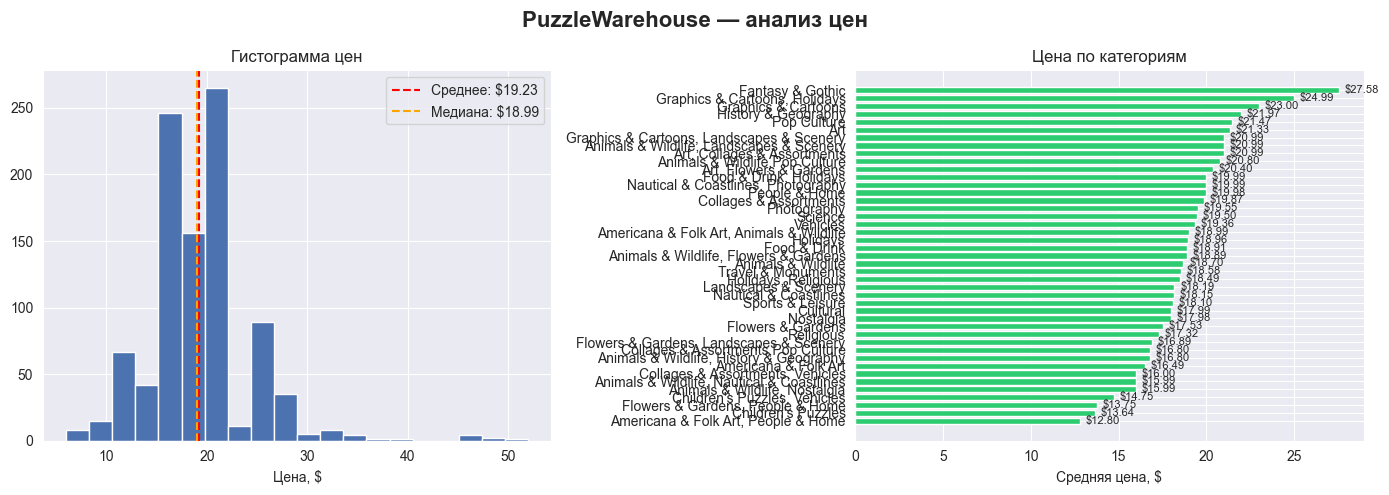

In [15]:
class PuzzleWarehouseAnalyzer:
    """Анализ цен puzzlewarehouse"""

    def __init__(self, df: pd.DataFrame):
        self.raw = df.copy()
        self.df = self._clean(df)

    def _clean(self, df: pd.DataFrame) -> pd.DataFrame:
        d = df.copy()
        d["price_usd"] = d["price"].apply(parse_price_usd)
        d["min_age"] = d["age"].apply(parse_age)
        d["pieces"] = pd.to_numeric(d["pieces"], errors="coerce")
        d["price_per_piece"] = d["price_usd"] / d["pieces"]
        d = d.dropna(subset=["price_usd", "pieces"])
        return d

    def summary(self) -> pd.DataFrame:
        return self.df[["price_usd", "pieces", "price_per_piece"]].describe().round(4)

    def by_category(self) -> pd.DataFrame:
        return (
            self.df.groupby("puzzle_category")["price_usd"]
            .agg(count="size", mean="mean", median="median", std="std")
            .round(2).sort_values("mean", ascending=False)
        )

    def by_age(self) -> pd.DataFrame:
        return (
            self.df.dropna(subset=["min_age"])
            .groupby("min_age")
            .agg(count=("price_usd", "size"), avg_price=("price_usd", "mean"),
                 avg_pieces=("pieces", "mean"))
            .round(2).sort_index()
        )

    def price_segments(self) -> pd.DataFrame:
        bins = [0, 15, 25, 40, 60, np.inf]
        labels = ["до $15", "$15–25", "$25–40", "$40–60", "$60+"]
        return (
            pd.cut(self.df["price_usd"], bins=bins, labels=labels)
            .value_counts().sort_index()
            .reset_index().rename(columns={"index": "segment", "price_usd": "count"})
        )

    def plot_static(self) -> plt.Figure:
        df = self.df
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle("PuzzleWarehouse — анализ цен", fontsize=16, fontweight="bold")
        ax = axes[0]
        ax.hist(df["price_usd"].dropna(), bins=20, color="#4C72B0", edgecolor="white")
        ax.axvline(df["price_usd"].mean(), color="red", ls="--",
                   label=f"Среднее: ${df['price_usd'].mean():.2f}")
        ax.axvline(df["price_usd"].median(), color="orange", ls="--",
                   label=f"Медиана: ${df['price_usd'].median():.2f}")
        ax.set_xlabel("Цена, $"); ax.legend()
        ax.set_title("Гистограмма цен")
        ax = axes[1]
        cat_df = df.groupby("puzzle_category")["price_usd"].mean().sort_values()
        bars = ax.barh(cat_df.index, cat_df.values, color="#2ECC71")
        ax.bar_label(bars, fmt="$%.2f", padding=4, fontsize=8)
        ax.set_xlabel("Средняя цена, $")
        ax.set_title("Цена по категориям")
        plt.tight_layout()
        return fig

    def run_dash(self, port: int = 8051):
        """Запуск дашборда"""
        df = self.df
        categories = sorted(df["puzzle_category"].dropna().unique())

        app = dash.Dash(__name__)
        app.layout = html.Div([
            html.H2("Анализ цен: PuzzleWarehouse", style={"textAlign": "center"}),
            html.Div([
                html.Label("Категория:"),
                dcc.Dropdown(
                    id="dd-cat",
                    options=[{"label": "Все", "value": "all"}] +
                            [{"label": c, "value": c} for c in categories],
                    value="all", clearable=False,
                ),
            ], style={"width": "300px", "padding": "10px"}),
            html.Div([
                dcc.Graph(id="wh-hist"),
                dcc.Graph(id="wh-bar"),
            ], style={"display": "grid", "gridTemplateColumns": "1fr 1fr", "gap": "12px"}),
        ])

        @app.callback(
            Output("wh-hist", "figure"),
            Output("wh-bar", "figure"),
            Input("dd-cat", "value"),
        )
        def update(cat):
            d = df.copy()
            if cat != "all":
                d = d[d["puzzle_category"] == cat]
            fig_hist = px.histogram(d, x="price_usd", nbins=20,
                                    title="Распределение цен",
                                    labels={"price_usd": "Цена, $"},
                                    template="plotly_white",
                                    color_discrete_sequence=["#4C72B0"])
            cat_df = (d.groupby("puzzle_category")["price_usd"]
                       .mean().reset_index().sort_values("price_usd"))
            fig_bar = px.bar(cat_df, x="price_usd", y="puzzle_category",
                             orientation="h", title="Средняя цена по категориям",
                             labels={"price_usd": "Цена, $", "puzzle_category": ""},
                             template="plotly_white", text_auto="$.2f")
            return fig_hist, fig_bar

        app.run(port=port, jupyter_mode="inline")


analyzer_wh = PuzzleWarehouseAnalyzer(df_full)
display(analyzer_wh.summary())
display(analyzer_wh.by_category())
display(analyzer_wh.by_age())
display(analyzer_wh.price_segments())
fig_wh = analyzer_wh.plot_static()
plt.show()
analyzer_wh.run_dash()

In [16]:
class WildberriesParser:
    """Парсер пазлов WB"""

    WB_BASE = "https://www.wildberries.ru"
    WB_SEARCH = "https://www.wildberries.ru/catalog/0/search.aspx?search=пазлы"

    DETAIL_FIELDS = [
        "Артикул",
        "Материал изделия",
        "Количество элементов",
        "Возрастные ограничения",
        "Страна производства",
        "Ширина собранного пазла",
        "Высота собранного пазла",
        "Цвет",
    ]

    def __init__(self, max_pages=3, delay=2.5):
        self.max_pages = max_pages
        self.delay = delay
        self.driver = None

    def _init_driver(self):
        opts = Options()
        opts.add_argument("--no-sandbox")
        opts.add_argument("--disable-dev-shm-usage")
        opts.add_argument("--disable-blink-features=AutomationControlled")
        opts.add_experimental_option("excludeSwitches", ["enable-automation"])
        opts.add_experimental_option("useAutomationExtension", False)
        opts.add_argument("--window-size=1920,1080")
        opts.add_argument(
            "user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/124.0.0.0 Safari/537.36"
        )
        service = Service(ChromeDriverManager().install())
        self.driver = webdriver.Chrome(service=service, options=opts)

        self.driver.execute_cdp_cmd("Page.addScriptToEvaluateOnNewDocument", {
            "source": "Object.defineProperty(navigator, 'webdriver', {get: () => undefined})"
        })

    def _scroll_page(self):
        """Прокрутка до конца"""
        last_h = self.driver.execute_script("return document.body.scrollHeight")
        while True:
            self.driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
            time.sleep(1.8)
            new_h = self.driver.execute_script("return document.body.scrollHeight")
            if new_h == last_h:
                break
            last_h = new_h

    def _collect_links(self):
        """Сбор ссылок с листинга"""
        links = []
        for page in range(1, self.max_pages + 1):
            url = f"{self.WB_SEARCH}&page={page}"
            self.driver.get(url)
            time.sleep(self.delay)
            self._scroll_page()

            soup = BeautifulSoup(self.driver.page_source, "html.parser")

            anchors = soup.find_all("a", class_=lambda c: c and "product-card__link" in c)
            if not anchors:
                print(f"  Страница {page}: карточки не найдены — останавливаемся.")
                break

            for a in anchors:
                href = a.get("href", "")
                if not href:
                    continue
                if not href.startswith("http"):
                    href = self.WB_BASE + href
                links.append(href)

            print(f"  Страница {page}: +{len(anchors)} ссылок (всего {len(links)})")

        return list(dict.fromkeys(links))

    @staticmethod
    def _extract_price(soup):
        """Цена со страницы"""
        for selector in [
            "button.priceBlockWalletPrice--RJGuT h3.mo-typography_color_danger",
            "ins.priceBlockFinalPrice--iToZR",
            "span.priceBlockOldPrice--qSWAf"
        ]:
            if tag := soup.select_one(selector):
                return tag.get_text(strip=True).replace('\xa0', ' ')
        return ""

    @staticmethod
    def _extract_characteristics(soup):
        """Характеристики товара"""
        result = {}

        section = soup.find("section", id="characteristics")
        if not section:
            section = soup

        for table in section.find_all("table"):
            for tr in table.find_all("tr"):
                th = tr.find("th")
                td = tr.find("td")
                if not th or not td:
                    continue

                key_span = th.find("span")
                key = key_span.get_text(strip=True) if key_span else th.get_text(strip=True)
                key = key.rstrip(":")

                btn = td.find("button")
                if btn:
                    val_span = btn.find("span")
                    val = val_span.get_text(strip=True) if val_span else btn.get_text(strip=True)
                else:
                    val_div = td.find("div")
                    val = val_div.get_text(strip=True) if val_div else td.get_text(strip=True)

                if key:
                    result[key] = val

        return result

    def _parse_product(self, url):
        """Парсинг одного товара"""
        try:
            self.driver.get(url)
            time.sleep(self.delay)
            soup = BeautifulSoup(self.driver.page_source, "html.parser")

            record = {"url": url}

            h1 = soup.find("h1")
            record["name"] = h1.get_text(strip=True) if h1 else ""

            brand_span = soup.find("span", class_=lambda c: c and "brand" in (c or "").lower())
            record["brand"] = brand_span.get_text(strip=True) if brand_span else ""

            record["price"] = self._extract_price(soup)

            for field in self.DETAIL_FIELDS:
                record[field] = ""

            chars = self._extract_characteristics(soup)
            for field in self.DETAIL_FIELDS:
                if field in chars:
                    record[field] = chars[field]

            return record

        except Exception as e:
            print(f"  [!] Ошибка {url}: {e}")
            return {"url": url}

    def run(self):
        """Запуск парсинга"""
        self._init_driver()
        try:
            print("=== Сбор ссылок ===")
            links = self._collect_links()
            print(f"Итого ссылок: {len(links)}\n=== Парсинг товаров ===")

            products = []
            for i, link in enumerate(links, 1):
                print(f"[{i}/{len(links)}] {link}")
                data = self._parse_product(link)
                products.append(data)
                time.sleep(self.delay)

            df = pd.DataFrame(products)
            cols_order = ["url", "name", "brand", "price"] + self.DETAIL_FIELDS
            existing = [c for c in cols_order if c in df.columns]
            rest = [c for c in df.columns if c not in existing]
            return df[existing + rest]

        finally:
            self.driver.quit()


wb_parser = WildberriesParser(max_pages=10, delay=2)
df_wb = wb_parser.run()
display(df_wb)

=== Сбор ссылок ===
  Страница 1: +61 ссылок (всего 61)
  Страница 2: +101 ссылок (всего 162)
  Страница 3: +101 ссылок (всего 263)
  Страница 4: +101 ссылок (всего 364)
  Страница 5: +101 ссылок (всего 465)
  Страница 6: +101 ссылок (всего 566)
  Страница 7: +101 ссылок (всего 667)
  Страница 8: +101 ссылок (всего 768)
  Страница 9: +101 ссылок (всего 869)
  Страница 10: +101 ссылок (всего 970)
Итого ссылок: 104
=== Парсинг товаров ===
[1/104] https://www.wildberries.ru/catalog/162692817/detail.aspx
[2/104] https://www.wildberries.ru/catalog/104520987/detail.aspx
[3/104] https://www.wildberries.ru/catalog/143593128/detail.aspx
[4/104] https://www.wildberries.ru/catalog/43829398/detail.aspx
[5/104] https://www.wildberries.ru/catalog/162692823/detail.aspx
[6/104] https://www.wildberries.ru/catalog/235188718/detail.aspx
[7/104] https://www.wildberries.ru/catalog/267869319/detail.aspx
[8/104] https://www.wildberries.ru/catalog/240769781/detail.aspx
[9/104] https://www.wildberries.ru/catal

,url,name,brand,price,Артикул,Материал изделия,Количество элементов,Возрастные ограничения,Страна производства,Ширина собранного пазла,Высота собранного пазла,Цвет
0,https://www.wildberries.ru/catalog/162692817/d...,,Puzzle Time,40 ₽,162692817,картон,54 элемента,3 года; 4 года; 5 лет,Россия,9 см,13 см,
1,https://www.wildberries.ru/catalog/104520987/d...,"5,0",Харди Гарди,719 ₽,104520987,картон,48,3+; 4+; 5+,Россия,63 см,46 см,
2,https://www.wildberries.ru/catalog/143593128/d...,,Puzzle Time,54 ₽,143593128,картон,24 элемента,от 3 лет; 4+; 5+,Россия,13 см,17 см,
3,https://www.wildberries.ru/catalog/43829398/de...,,Puzzle Time,95 ₽,43829398,картон,60 элементов,3+; 4+; от 3 лет,Россия,33 см,,
4,https://www.wildberries.ru/catalog/162692823/d...,,Puzzle Time,84 ₽,,,,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...
99,https://www.wildberries.ru/catalog/224373674/d...,,Hatber,158 ₽,224373674,картон,250,5+; 6+; 7+,Россия,28 см,40 см,
100,https://www.wildberries.ru/catalog/12751837/de...,,Рыжий кот.,104 ₽,12751837,картон,16 элементов; 25 элементов; 36 элементов,3+,Россия,,,
101,https://www.wildberries.ru/catalog/11888981/de...,"4,9",Origami,136 ₽,11888981,картон; бумага,500 элементов,12 +,Россия,47 см,33 см,
102,https://www.wildberries.ru/catalog/231448316/d...,,Zufa,352 ₽,231448316,"дерево, бумага.",183,3+,Россия,19 см,,


ОБЩАЯ СТАТИСТИКА


,price_rub,pieces,price_per_piece,min_age
count,104.00,98.00,98.00,96.00
mean,448.98,146.38,9.71,4.96
std,673.91,194.30,15.35,3.23
min,40.00,6.00,0.27,1.00
25%,205.25,30.00,1.56,3.00
50%,282.00,60.00,3.96,3.00
75%,533.25,160.00,11.58,6.00
max,5687.00,1000.00,95.42,14.00


СТАТИСТИКА ПО БРЕНДАМ


,count,mean_price,median_price,min_price,max_price
brand,,,,,
DAVICI,2,4754.00,4754.0,3821.0,5687.0
Рыжий кот,1,1287.00,1287.0,1287.0,1287.0
MILAND,1,1060.00,1060.0,1060.0,1060.0
Мудрая Куница,2,979.00,979.0,813.0,1145.0
TREEARTI,1,871.00,871.0,871.0,871.0
,2,762.00,762.0,466.0,1058.0
Special Gift Pack,1,745.00,745.0,745.0,745.0
Boberbox,1,700.00,700.0,700.0,700.0
Харди Гарди,4,659.25,644.5,629.0,719.0


СТАТИСТИКА ПО КОЛИЧЕСТВУ ЭЛЕМЕНТОВ


...

,count,avg_price,avg_pieces
min_age,,,
1.0,3,273.00,36.33
2.0,3,230.00,22.00
3.0,47,362.17,49.17
4.0,1,528.00,100.00
5.0,11,345.45,113.55
6.0,15,283.33,325.27
7.0,3,285.33,241.33
8.0,2,222.00,192.50
10.0,2,2065.50,142.00


ЦЕНОВЫЕ СЕГМЕНТЫ


,segment,count
0,до 100₽,11
1,100–300₽,47
2,300–500₽,18
3,500–1000₽,22
4,1000–2000₽,4
5,2000₽+,2


СЕГМЕНТЫ ПО КОЛИЧЕСТВУ ЭЛЕМЕНТОВ


,segment,count
0,до 50,39
1,50–100,20
2,100–200,19
3,200–500,18
4,500–1000,2
5,1000+,0


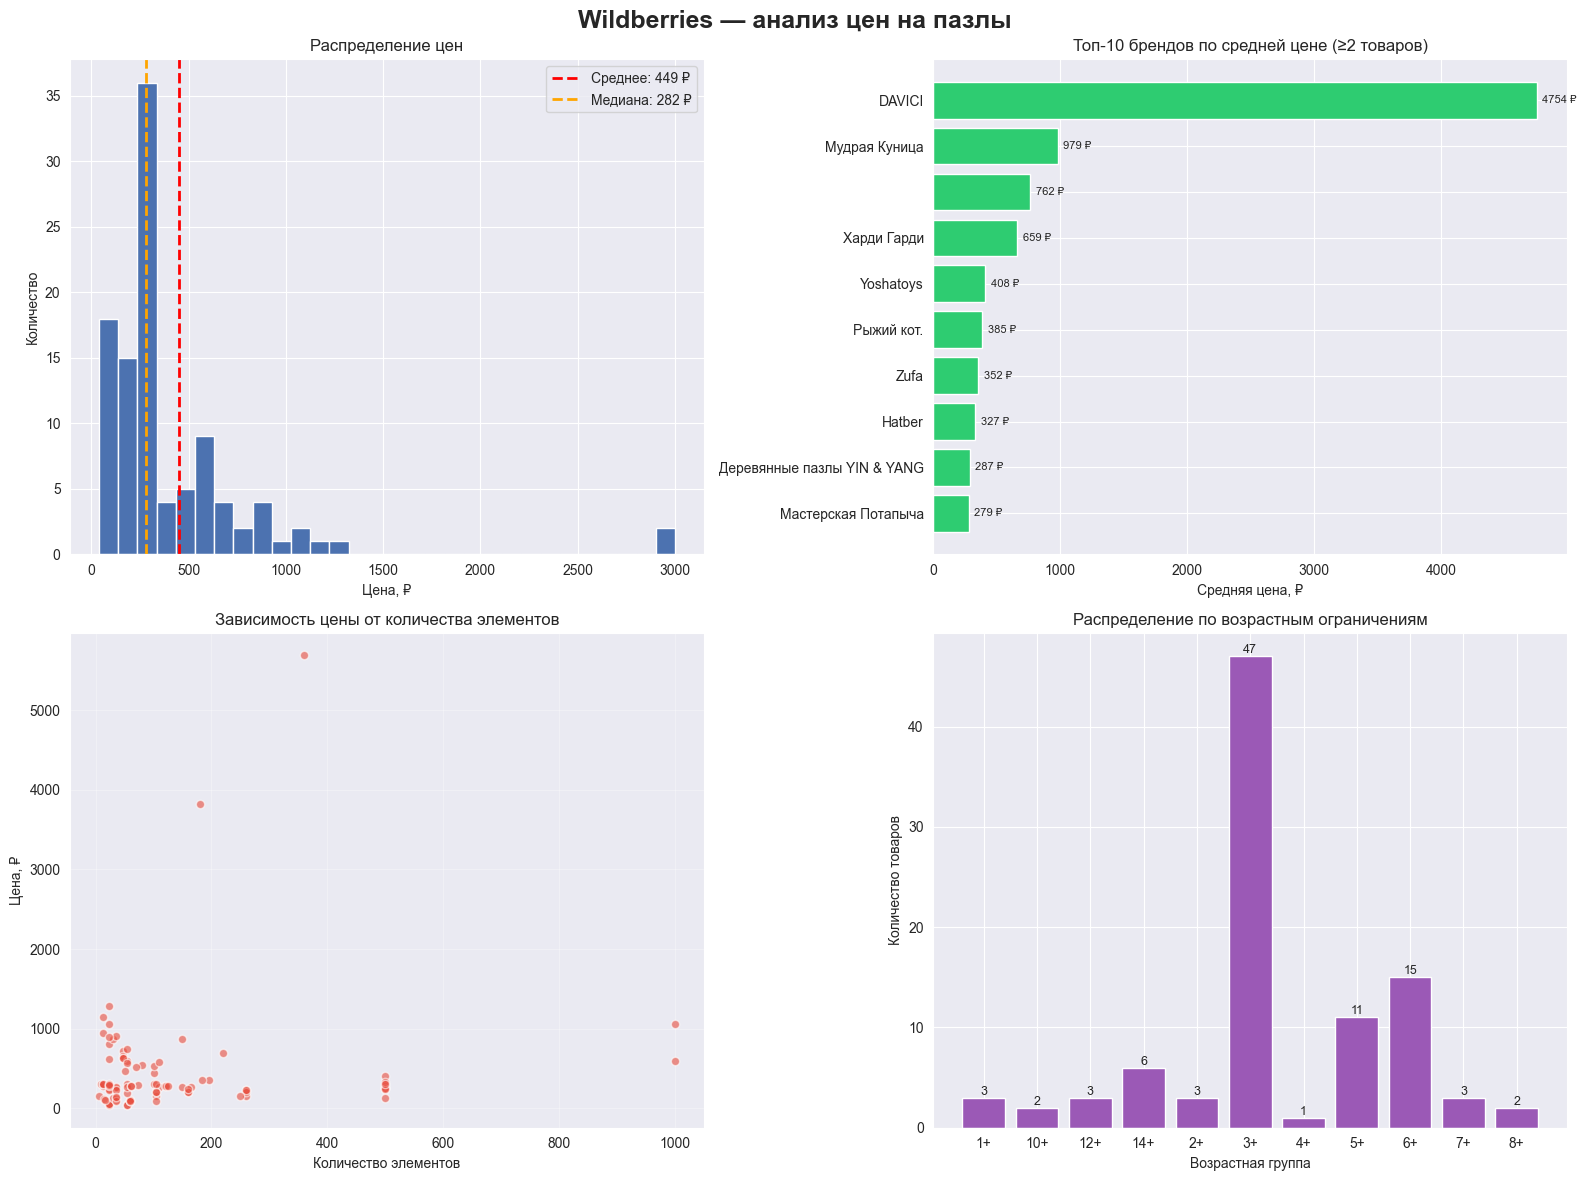

In [17]:
class WildberriesPuzzleAnalyzer:
    """Анализ пазлов WB"""

    def __init__(self, df):
        self.raw = df.copy()
        self.df = self._clean(df)

    def _parse_price_rub(self, price_str):
        """Цена в число"""
        if pd.isna(price_str) or not isinstance(price_str, str):
            return None
        match = re.search(r'[\d\s]+', price_str)
        if match:
            return float(match.group().replace(' ', '').replace('\u00A0', ''))
        return None

    def _parse_pieces(self, pieces_str):
        """Элементы в число"""
        if pd.isna(pieces_str) or not isinstance(pieces_str, str):
            return None
        match = re.search(r'\d+', pieces_str)
        if match:
            return float(match.group())
        return None

    def _parse_age(self, age_str):
        """Возраст в число"""
        if pd.isna(age_str) or not isinstance(age_str, str):
            return None
        numbers = re.findall(r'\d+', age_str)
        if numbers:
            return float(min(int(n) for n in numbers))
        return None

    def _parse_dimension(self, dim_str):
        """Размер в см"""
        if pd.isna(dim_str) or not isinstance(dim_str, str):
            return None
        match = re.search(r'(\d+(?:\.\d+)?)\s*см', dim_str)
        if match:
            return float(match.group(1))
        return None

    def _clean(self, df):
        d = df.copy()

        d["price_rub"] = d["price"].apply(self._parse_price_rub)
        d["pieces"] = d["Количество элементов"].apply(self._parse_pieces)
        d["min_age"] = d["Возрастные ограничения"].apply(self._parse_age)
        d["width_cm"] = d["Ширина собранного пазла"].apply(self._parse_dimension)
        d["height_cm"] = d["Высота собранного пазла"].apply(self._parse_dimension)

        d["area_cm2"] = d["width_cm"] * d["height_cm"]
        d["price_per_piece"] = d["price_rub"] / d["pieces"]
        d["price_per_cm2"] = d["price_rub"] / d["area_cm2"]

        d = d.dropna(subset=["price_rub"])
        return d

    def summary(self):
        """Общая статистика"""
        cols = ["price_rub", "pieces", "price_per_piece", "min_age"]
        available_cols = [c for c in cols if c in self.df.columns]
        return self.df[available_cols].describe().round(2)

    def by_brand(self):
        """Статистика по брендам"""
        return (
            self.df.groupby("brand")["price_rub"]
            .agg(
                count="size",
                mean_price="mean",
                median_price="median",
                min_price="min",
                max_price="max"
            )
            .round(2)
            .sort_values("mean_price", ascending=False)
        )

    def by_pieces(self):
        """Статистика по элементам"""
        return (
            self.df.dropna(subset=["pieces"])
            .groupby("pieces")
            .agg(
                count=("price_rub", "size"),
                avg_price=("price_rub", "mean"),
                avg_price_per_piece=("price_per_piece", "mean")
            )
            .round(2)
            .sort_index()
        )

    def by_age(self):
        """Статистика по возрасту"""
        return (
            self.df.dropna(subset=["min_age"])
            .groupby("min_age")
            .agg(
                count=("price_rub", "size"),
                avg_price=("price_rub", "mean"),
                avg_pieces=("pieces", "mean")
            )
            .round(2)
            .sort_index()
        )

    def by_material(self):
        """Статистика по материалу"""
        return (
            self.df.dropna(subset=["Материал изделия"])
            .groupby("Материал изделия")["price_rub"]
            .agg(count="size", mean_price="mean", median_price="median")
            .round(2)
            .sort_values("mean_price", ascending=False)
        )

    def price_segments(self):
        """Ценовые сегменты"""
        bins = [0, 100, 300, 500, 1000, 2000, np.inf]
        labels = ["до 100₽", "100–300₽", "300–500₽", "500–1000₽", "1000–2000₽", "2000₽+"]
        result = (
            pd.cut(self.df["price_rub"], bins=bins, labels=labels)
            .value_counts()
            .sort_index()
            .reset_index()
        )
        result.columns = ["segment", "count"]
        return result

    def pieces_segments(self):
        """Сегменты по элементам"""
        bins = [0, 50, 100, 200, 500, 1000, np.inf]
        labels = ["до 50", "50–100", "100–200", "200–500", "500–1000", "1000+"]
        pieces_data = self.df.dropna(subset=["pieces"])
        result = (
            pd.cut(pieces_data["pieces"], bins=bins, labels=labels)
            .value_counts()
            .sort_index()
            .reset_index()
        )
        result.columns = ["segment", "count"]
        return result

    def plot_static(self):
        """Статический график"""
        df = self.df.dropna(subset=["price_rub"])

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle("Wildberries — анализ цен на пазлы", fontsize=18, fontweight="bold")

        ax = axes[0, 0]
        ax.hist(df["price_rub"].clip(upper=3000), bins=30, color="#4C72B0", edgecolor="white")
        ax.axvline(df["price_rub"].mean(), color="red", ls="--", linewidth=2,
                   label=f"Среднее: {df['price_rub'].mean():.0f} ₽")
        ax.axvline(df["price_rub"].median(), color="orange", ls="--", linewidth=2,
                   label=f"Медиана: {df['price_rub'].median():.0f} ₽")
        ax.set_xlabel("Цена, ₽")
        ax.set_ylabel("Количество")
        ax.set_title("Распределение цен")
        ax.legend()

        ax = axes[0, 1]
        brand_stats = df.groupby("brand").agg(
            mean_price=("price_rub", "mean"),
            count=("price_rub", "size")
        ).query("count >= 2").sort_values("mean_price", ascending=True).tail(10)

        bars = ax.barh(brand_stats.index, brand_stats["mean_price"], color="#2ECC71")
        ax.bar_label(bars, fmt="%.0f ₽", padding=4, fontsize=8)
        ax.set_xlabel("Средняя цена, ₽")
        ax.set_title("Топ-10 брендов по средней цене (≥2 товаров)")

        ax = axes[1, 0]
        scatter_data = df.dropna(subset=["pieces"])
        ax.scatter(scatter_data["pieces"], scatter_data["price_rub"],
                   alpha=0.6, c="#E74C3C", edgecolors="white")
        ax.set_xlabel("Количество элементов")
        ax.set_ylabel("Цена, ₽")
        ax.set_title("Зависимость цены от количества элементов")
        ax.grid(True, alpha=0.3)

        ax = axes[1, 1]
        age_data = df.dropna(subset=["min_age"]).copy()
        age_data["age_group"] = age_data["min_age"].apply(
            lambda x: f"{int(x)}+" if pd.notna(x) else "Н/Д"
        )
        age_counts = age_data["age_group"].value_counts().sort_index()
        bars = ax.bar(age_counts.index, age_counts.values, color="#9B59B6", edgecolor="white")
        ax.bar_label(bars, fontsize=9)
        ax.set_xlabel("Возрастная группа")
        ax.set_ylabel("Количество товаров")
        ax.set_title("Распределение по возрастным ограничениям")

        plt.tight_layout()
        return fig

    def run_dash(self, port=8052):
        """Дашборд"""
        df = self.df.dropna(subset=["price_rub"]).copy()
        brands = sorted(df["brand"].dropna().unique())

        app = dash.Dash(__name__)
        app.layout = html.Div([
            html.H1("Анализ пазлов WB", style={"textAlign": "center"}),

            dcc.Dropdown(
                id="brand-dropdown",
                options=[{"label": "Все бренды", "value": "all"}] +
                        [{"label": b, "value": b} for b in brands],
                value="all",
                clearable=False,
                style={"width": "300px", "margin": "0 auto"}
            ),

            html.Div([
                dcc.Graph(id="price-hist"),
                dcc.Graph(id="scatter-plot"),
            ], style={"display": "grid", "gridTemplateColumns": "1fr 1fr", "gap": "12px"}),
        ])

        @app.callback(
            [Output("price-hist", "figure"),
             Output("scatter-plot", "figure")],
            [Input("brand-dropdown", "value")]
        )
        def update(selected_brand):
            d = df.copy()
            if selected_brand != "all":
                d = d[d["brand"] == selected_brand]

            fig_hist = px.histogram(d, x="price_rub", nbins=30, title="Цены")
            fig_hist.add_vline(x=d["price_rub"].mean(), line_dash="dash", line_color="red")

            scatter_data = d.dropna(subset=["pieces"])
            fig_scatter = px.scatter(scatter_data, x="pieces", y="price_rub",
                                     title="Цена vs Элементы",
                                     hover_data=["name", "brand"])

            return fig_hist, fig_scatter

        app.run(port=port, debug=False)



df_full = df_wb

analyzer_wb = WildberriesPuzzleAnalyzer(df_full)


print("ОБЩАЯ СТАТИСТИКА")
display(analyzer_wb.summary())

print("СТАТИСТИКА ПО БРЕНДАМ")
display(analyzer_wb.by_brand())

print("СТАТИСТИКА ПО КОЛИЧЕСТВУ ЭЛЕМЕНТОВ")
display(analyzer_wb.by_pieces())


print("СТАТИСТИКА ПО ВОЗРАСТУ")
display(analyzer_wb.by_age())


print("ЦЕНОВЫЕ СЕГМЕНТЫ")
display(analyzer_wb.price_segments())


print("СЕГМЕНТЫ ПО КОЛИЧЕСТВУ ЭЛЕМЕНТОВ")
display(analyzer_wb.pieces_segments())

fig_wb = analyzer_wb.plot_static()
plt.show()

analyzer_wb.run_dash(port=8052)

Гипотеза 1 — Количество элементов: r = -0.098, p = 0.3386


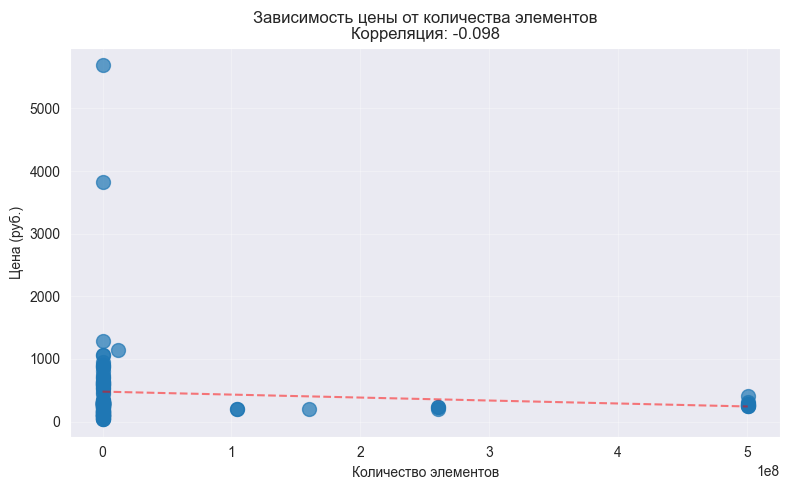

Гипотеза 2 — Площадь пазла: r = 0.120, p = 0.5001


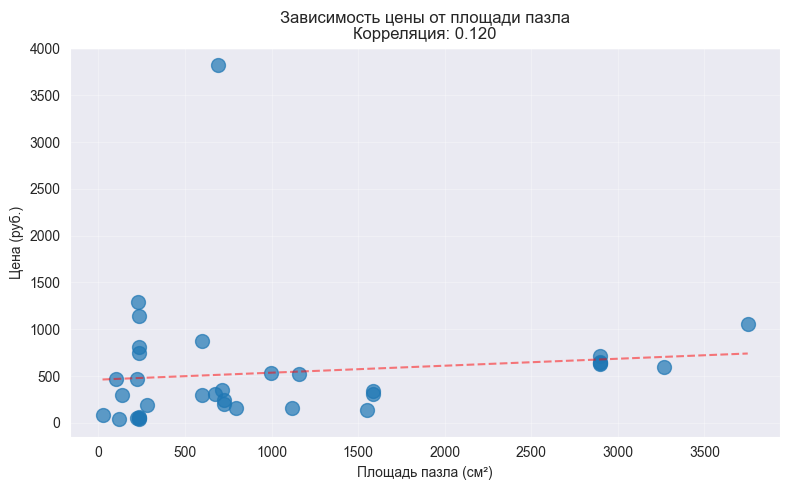

In [19]:
def analyze_puzzle_hypotheses(data):
    """
    Проверка гипотез о цене
    """

    def clean_numeric(series, keep_dot=False):
        pattern = r'[^\d.]' if keep_dot else r'[^\d]'
        return pd.to_numeric(series.str.replace(pattern, '', regex=True), errors='coerce')

    df = data.copy()
    df['price_clean'] = clean_numeric(df['price'], keep_dot=True)
    df['elements'] = clean_numeric(df['Количество элементов'])
    df['width_cm'] = clean_numeric(df['Ширина собранного пазла'], keep_dot=True)
    df['height_cm'] = clean_numeric(df['Высота собранного пазла'], keep_dot=True)
    df['area_sq_cm'] = df['width_cm'] * df['height_cm']

    # Гипотеза 1: Количество элементов
    h1_data = df[df['elements'].notna()]
    correlation1, p_value1 = stats.pearsonr(h1_data['elements'], h1_data['price_clean'])
    print(f"Гипотеза 1 — Количество элементов: r = {correlation1:.3f}, p = {p_value1:.4f}")

    plt.figure(figsize=(8, 5))
    plt.scatter(h1_data['elements'], h1_data['price_clean'], alpha=0.7, s=100)
    z = np.polyfit(h1_data['elements'], h1_data['price_clean'], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(h1_data['elements'].min(), h1_data['elements'].max(), 100)
    plt.plot(x_trend, p(x_trend), "r--", alpha=0.5)
    plt.xlabel('Количество элементов')
    plt.ylabel('Цена (руб.)')
    plt.title(f'Зависимость цены от количества элементов\nКорреляция: {correlation1:.3f}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Гипотеза 2: Площадь пазла
    h2_data = df[df['area_sq_cm'].notna()]
    correlation2, p_value2 = stats.pearsonr(h2_data['area_sq_cm'], h2_data['price_clean'])
    print(f"Гипотеза 2 — Площадь пазла: r = {correlation2:.3f}, p = {p_value2:.4f}")

    plt.figure(figsize=(8, 5))
    plt.scatter(h2_data['area_sq_cm'], h2_data['price_clean'], alpha=0.7, s=100)
    z = np.polyfit(h2_data['area_sq_cm'], h2_data['price_clean'], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(h2_data['area_sq_cm'].min(), h2_data['area_sq_cm'].max(), 100)
    plt.plot(x_trend, p(x_trend), "r--", alpha=0.5)
    plt.xlabel('Площадь пазла (см²)')
    plt.ylabel('Цена (руб.)')
    plt.title(f'Зависимость цены от площади пазла\nКорреляция: {correlation2:.3f}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df


data = df_wb
analyzed_data = analyze_puzzle_hypotheses(data)